# Day 5 · Một notebook tự kiểm từ đầu đến cuối

**Dành cho học viên · hỗ trợ tự kiểm, không chấm điểm.** Bạn vẫn vẽ mask trong CVAT và nộp link fork trên VLearn. Notebook này chỉ đọc ảnh/ZIP của bạn, không tạo mask hoặc đáp án.

**Làm theo đúng thứ tự:** (0) chạy ô kiểm môi trường → (1) dán link fork ở ô kế tiếp → (2) nếu ZIP chưa có trên fork, upload ZIP tạm → (3) chạy các ô nhận ảnh, semantic, instance, panoptic → (4) kiểm bài nộp. Bấm nút ▶ cạnh từng ô, đợi ô chạy xong mới xuống ô sau. Đừng bấm *Run all* trước khi điền link fork. Nếu không dùng notebook, làm đầy đủ theo `lab-guide.html`.

## BƯỚC 0 · Thư viện cần dùng

Trên Colab, chạy ô dưới trước. Notebook chỉ cần **Python 3.10+ và IPython** (để hiện ảnh); nếu thiếu IPython, ô sẽ tự cài và báo kết quả. **Không cài `requirements.txt`**: NumPy, Pillow, pycocotools trong đó phục vụ mã chấm riêng, không cần cho tự kiểm/nộp bài. Git được dùng để tải fork; nếu không có Git, ô kế tiếp sẽ báo rõ. Nếu mạng/cài đặt lỗi, bạn vẫn làm bài trên CVAT và nộp bằng GitHub, không mất quyền làm bài.

In [1]:
# BƯỚC 0 — kiểm tra môi trường. Chạy ô này trước, không cần sửa dòng nào.
import importlib.util
import subprocess
import sys

print("Python:", sys.version.split()[0])
if sys.version_info < (3, 10):
    raise RuntimeError("Cần Python 3.10 trở lên. Hãy dùng Google Colab hoặc báo coach nếu máy lớp quá cũ.")

# Notebook chỉ dùng IPython để hiện ảnh. Các kiểm tra ZIP còn lại dùng thư viện chuẩn Python.
if importlib.util.find_spec("IPython") is None:
    print("Chưa có IPython; đang cài vào đúng môi trường Python của notebook...")
    try:
        subprocess.run([sys.executable, "-m", "pip", "install", "IPython"], check=True)
    except subprocess.CalledProcessError as exc:
        raise RuntimeError("Không cài được IPython. Báo coach; bạn vẫn làm và nộp bài bằng CVAT/GitHub, không cần notebook.") from exc
else:
    print("IPython đã có — không cần cài lại.")
print("SẴN SÀNG: chuyển sang ô BƯỚC 1 bên dưới.")


Python: 3.13.15
IPython đã có — không cần cài lại.
SẴN SÀNG: chuyển sang ô BƯỚC 1 bên dưới.


## BƯỚC 1 · Kết nối đúng fork của bạn

Trong ô kế tiếp, sửa **duy nhất** `FORK_URL = ""` thành URL gốc fork cá nhân, ví dụ `FORK_URL = "https://github.com/ten-ban/Day5-Segmentation-Lab-Student"`. Không dán link repo đề bài, link một file, `/tree/main`, mật khẩu hay token. Trên Colab, ô tải repo công khai của bạn một lần; trên Jupyter local, mở notebook từ thư mục repo và để `FORK_URL` trống. Nếu vừa push file mới mà Colab vẫn thấy bản cũ, chọn **Runtime → Restart runtime** rồi chạy lại từ BƯỚC 0.

In [2]:
from pathlib import Path
import importlib.util
import sys
import re
import shutil
import subprocess

# Trên Colab: dán URL fork của BẠN, ví dụ https://github.com/ten-ban/Day5-Segmentation-Lab-Student
FORK_URL = "https://github.com/theanhdt04/K4-L2-DAY05-NguyenTheAnh-2A202602138-Segmentation.git"
IN_COLAB = importlib.util.find_spec("google.colab") is not None
if IN_COLAB:
    assert shutil.which("git"), "Colab không thấy Git để tải fork. Thử Runtime > Restart runtime hoặc báo coach."
    assert re.fullmatch(r"https://github\.com/[A-Za-z0-9_.-]+/[A-Za-z0-9_.-]+(?:\.git)?/?", FORK_URL), "Dán link fork GitHub vào FORK_URL rồi chạy lại ô này."
    root = Path("/content/day5-student-fork")
    if not (root / "data/manifest.json").is_file():
        subprocess.run(["git", "clone", "--depth", "1", FORK_URL, str(root)], check=True)
    else:
        existing_url = subprocess.run(["git", "-C", str(root), "remote", "get-url", "origin"], check=True, capture_output=True, text=True).stdout.strip()
        assert existing_url.rstrip("/").removesuffix(".git") == FORK_URL.rstrip("/").removesuffix(".git"), "Phiên Colab đang có fork khác. Chọn Runtime > Restart runtime rồi chạy lại."
        print("Đang dùng bản fork đã tải trong phiên Colab này; Runtime > Restart để tải lại bản mới.")
else:
    root = next((p for p in [Path.cwd(), *Path.cwd().parents] if (p / "data/manifest.json").is_file()), None)
    assert root is not None, "Mở notebook từ thư mục repo Day 5 (hoặc thư mục notebooks/)."
sys.path.insert(0, str(root / "scripts"))
from inspect_submissions import task_registry, expected_for, inspect_task
tasks = task_registry(root)
exports = root / "submissions"
exports.mkdir(exist_ok=True)
print("Repo:", root)
print("Thư mục export:", exports)
print("Đã nhận", len(tasks), "task. Nếu chưa push ZIP lên fork, dùng ô upload tạm tiếp theo.")


Repo: /content/day5-student-fork
Thư mục export: /content/day5-student-fork/submissions
Đã nhận 9 task. Nếu chưa push ZIP lên fork, dùng ô upload tạm tiếp theo.


## BƯỚC 2 · Đưa ZIP CVAT vào Colab nếu chưa push

Nếu đã push ZIP vào `submissions/` trên fork, cứ chạy ô sau với `UPLOAD_ZIPS = False`. Nếu chưa push: tìm ZIP CVAT trong thư mục Downloads của máy, đổi tên theo mã task (ví dụ `easy_semantic.zip`), sửa thành `UPLOAD_ZIPS = True`, bấm ▶ và chọn các ZIP. Dòng **Đã nhận** xác nhận file nằm tạm trong Colab; nó **không tự push lên fork**. Không upload dữ liệu cá nhân hoặc dữ liệu không được phép đưa lên Colab.

In [3]:
# Tùy chọn: nếu ZIP CVAT chưa được push lên fork, đổi thành True và chạy ô này.
# Colab chỉ giữ file tạm trong phiên làm việc; bạn vẫn phải upload ZIP lên fork để nộp.
UPLOAD_ZIPS = False
if not UPLOAD_ZIPS:
    print("Không upload ZIP tạm. Notebook sẽ đọc ZIP hiện có trong fork/thư mục submissions/.")
else:
    assert IN_COLAB, "Ô upload này chỉ dành cho Google Colab."
    from google.colab import files
    uploaded = files.upload()
    for filename, data in uploaded.items():
        if filename != Path(filename).name or not filename.endswith(".zip") or Path(filename).stem not in tasks:
            print("Bỏ qua file không đúng mã task:", filename)
            continue
        target = exports / filename
        target.write_bytes(data)
        print("Đã nhận:", target.name)
    print("Lưu ý: file tạm này chưa lên GitHub. Cuối buổi vẫn phải upload ZIP vào fork.")


Không upload ZIP tạm. Notebook sẽ đọc ZIP hiện có trong fork/thư mục submissions/.


## BƯỚC 3 · Kiểm bộ ảnh và class trước khi vẽ

Ô sau in 9 task, 14 ảnh và tên class của từng task. Đây là **danh sách cần đối chiếu với CVAT**, không phải đáp án mask. Nếu tổng điểm không phải 100 hoặc thiếu ảnh, dừng và kiểm lại link fork/bộ dữ liệu; không thay bằng ảnh khác.

In [4]:
for name, info in tasks.items():
    images, classes = expected_for(name, info, root)
    export_format = "Segmentation mask 1.1" if info["type"] == "semantic" else "COCO 1.0"
    print(f"{name:18} {info['type']:9} {len(images)} ảnh · {info['weight']} điểm · {export_format}")
    print("  ảnh:", ", ".join(sorted(images)))
    print("  class:", ", ".join(sorted(classes)))
print("Tổng điểm tối đa:", sum(info["weight"] for info in tasks.values()))


easy_semantic      semantic  3 ảnh · 20 điểm · Segmentation mask 1.1
  ảnh: 7ee6d192-89e2408b.jpg, 817bca71-00000000.jpg, 81ae7cbb-6bc63a4a.jpg
  class: building, road, sidewalk, sky, vegetation
medium_instance    instance  3 ảnh · 32 điểm · COCO 1.0
  ảnh: 000000181542.jpg, 000000373353.jpg, 000000458325.jpg
  class: bicycle, bus, car, motorcycle, person, truck
hard_panoptic      panoptic  2 ảnh · 30 điểm · COCO 1.0
  ảnh: 000000350023.jpg, 000000460147.jpg
  class: bicycle, building, bus, car, motorcycle, person, road, sidewalk, sky, traffic light, truck, vegetation
cp1_holes          instance  1 ảnh · 3 điểm · COCO 1.0
  ảnh: 000000144300.jpg
  class: bicycle, bus, car, motorcycle, person, truck
cp2_slice          instance  1 ảnh · 3 điểm · COCO 1.0
  ảnh: 000000017627.jpg
  class: bicycle, bus, car, motorcycle, person, truck
cp5_occlusion      instance  1 ảnh · 3 điểm · COCO 1.0
  ảnh: 000000336232.jpg
  class: bicycle, bus, car, motorcycle, person, truck
cp3_thin           semanti

## Xem một ảnh thực

Ảnh bên dưới là ảnh trong task, không có đường biên hay đáp án. Hãy đối chiếu tên file với CVAT khi tạo task. Đừng nộp ảnh này thay mask.

easy_semantic 7ee6d192-89e2408b.jpg


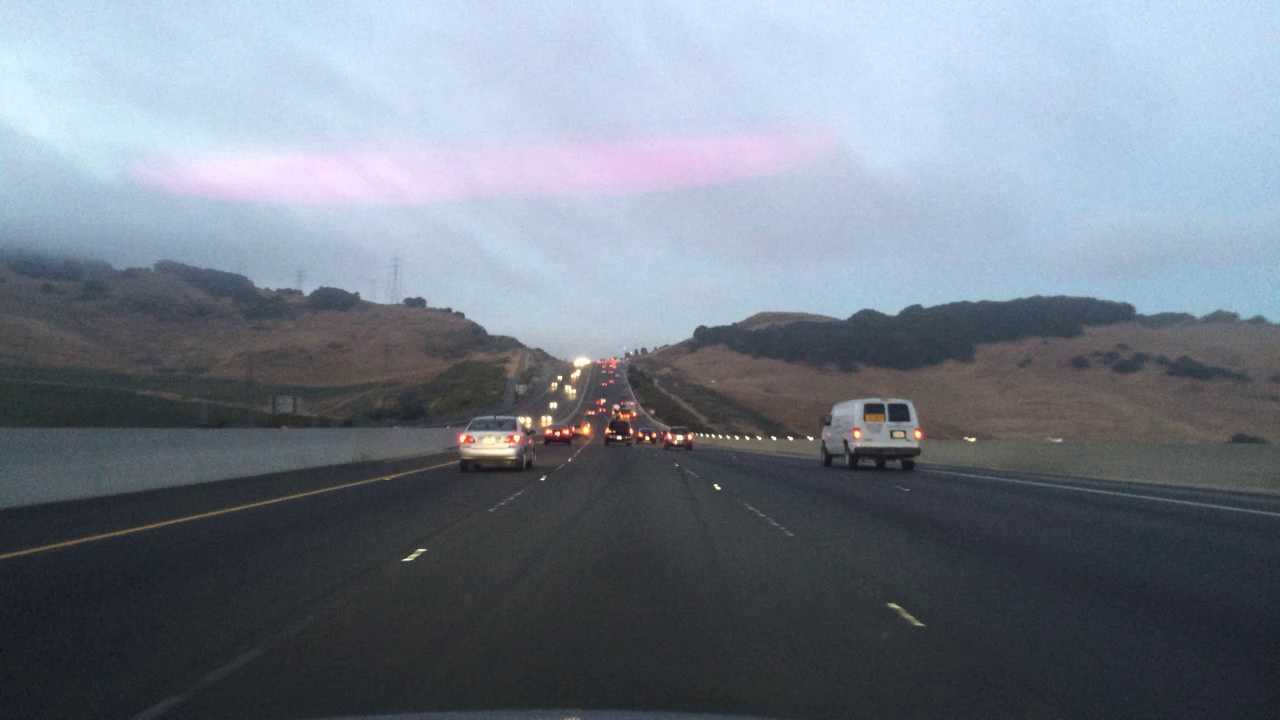

In [5]:
from IPython.display import display, Image
task_name = "easy_semantic"  # đổi sang một mã task trong bảng trên nếu cần
image_file = sorted((root / "data" / tasks[task_name]["path"] / "images").glob("*.jpg"))[0]
print(task_name, image_file.name)
display(Image(filename=str(image_file), width=760))


## Tự nhắc trước khi vẽ trong CVAT

1. Tạo task đúng mã, đưa đúng ảnh và class vừa in ở trên vào CVAT. 2. Vẽ mask, xem lại rìa và số object, bấm **Save**. 3. Export đúng format, đổi tên ZIP theo mã task. 4. Chạy phần QC bên dưới.

- **Semantic:** mỗi pixel thuộc một lớp vùng; không phải một object riêng.
- **Instance:** mỗi vật đếm được là một mask riêng.
- **Panoptic:** vừa stuff vừa từng thing.
- Không có SAM vẫn dùng Brush/Polygon; notebook không phụ thuộc SAM. Chi tiết thao tác có ảnh ở `lab-guide.html` trong fork.

# 04 · Tự kiểm semantic

Áp dụng cho `easy_semantic`, `cp3_thin`, `cp4_curb`, `cp6_coverage`. Sau khi Save trong CVAT, export **Segmentation mask 1.1** rồi đặt ZIP vào `submissions/<mã_task>.zip` trên fork hoặc upload tạm ở BƯỚC 2. Ô sau kiểm **tên ảnh, PNG mask và labelmap**, không kiểm đường biên đúng hay chấm điểm.

**Đọc kết quả:** `CHƯA XUẤT` = chưa có ZIP, cứ tiếp tục CVAT; `LỖI` = đọc dòng `SỬA`, quay lại CVAT/đổi đúng ZIP rồi export lại; `OK` = cấu trúc có thể đọc, vẫn phải kiểm mask bằng mắt; `KIỂM` = cảnh báo cần xem lại.

In [6]:
semantic_names = [name for name, info in tasks.items() if info["type"] == "semantic"]
for name in semantic_names:
    result = inspect_task(name, exports / f"{name}.zip", root)
    status = "LỖI" if result["errors"] else ("CHƯA XUẤT" if not Path(result["file"]).exists() else "OK")
    print("\n", name, "·", status)
    print("  ảnh mask:", ", ".join(result["details"].get("mask_images", [])) or "—")
    for note in result["errors"]: print("  SỬA:", note)
    for note in result["warnings"]: print("  KIỂM:", note)



 easy_semantic · LỖI
  ảnh mask: 7ee6d192-89e2408b.jpg, 817bca71-00000000.jpg, 81ae7cbb-6bc63a4a.jpg
  SỬA: label ngoài classes.json: bus, car, truck, van

 cp3_thin · CHƯA XUẤT
  ảnh mask: —
  KIỂM: chưa có ZIP; ghi trong REPORT.md nếu chưa kịp

 cp4_curb · CHƯA XUẤT
  ảnh mask: —
  KIỂM: chưa có ZIP; ghi trong REPORT.md nếu chưa kịp

 cp6_coverage · CHƯA XUẤT
  ảnh mask: —
  KIỂM: chưa có ZIP; ghi trong REPORT.md nếu chưa kịp


## Xem thử một mask semantic

Trong ô sau, giữ `task_name = "easy_semantic"` hoặc đổi sang một task semantic khác. Nếu chưa có ZIP, thông báo `Chưa có ZIP` là bình thường. Nếu hiện mask, so với **ảnh gốc trong CVAT**: màu chỉ giúp nhìn vùng, không chứng minh mép road/sidewalk, cột mảnh hay lỗ phủ đúng.

Mask: SegmentationClass/7ee6d192-89e2408b.png


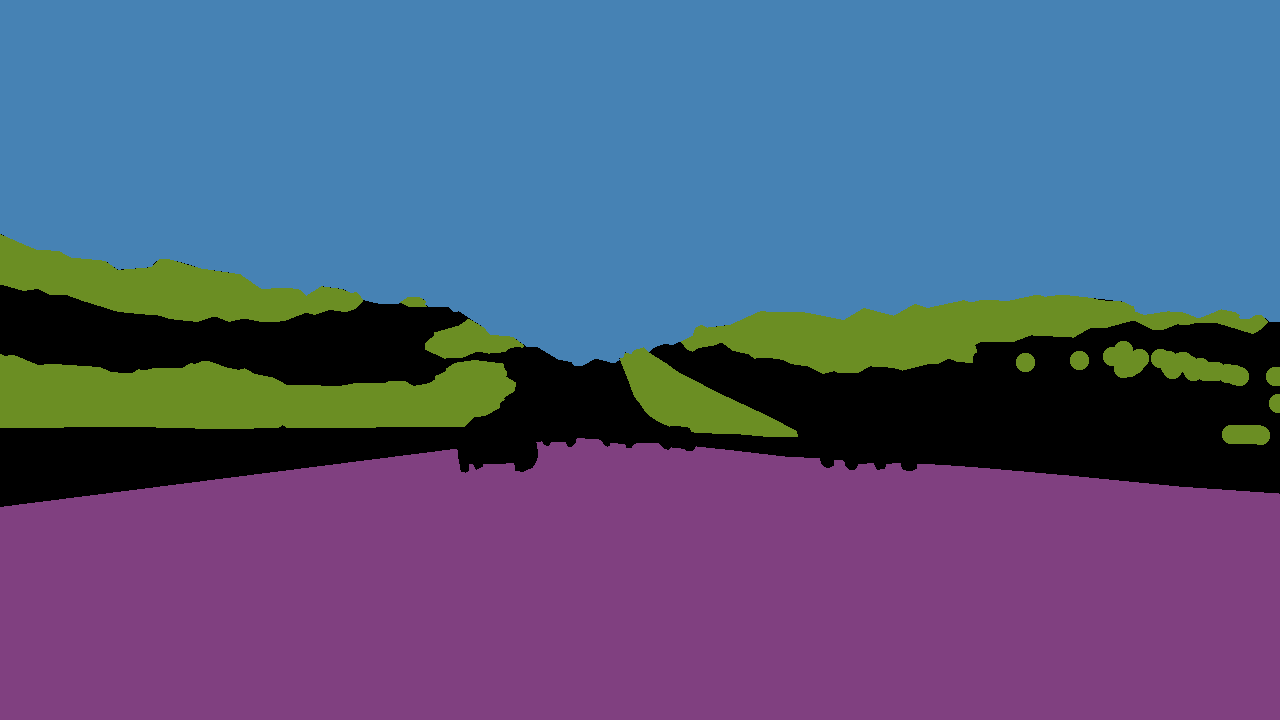

In [7]:
import zipfile
from IPython.display import display, Image
task_name = "easy_semantic"
assert task_name in semantic_names, "Chọn một task semantic đã in ở trên."
zip_path = exports / f"{task_name}.zip"
if zip_path.is_file():
    try:
        with zipfile.ZipFile(zip_path) as archive:
            masks = sorted(n for n in archive.namelist() if "SegmentationClass/" in n and n.endswith(".png"))
            if masks:
                print("Mask:", masks[0])
                display(Image(data=archive.read(masks[0]), width=760))
            else:
                print("Không có mask SegmentationClass; kiểm lại format export.")
    except zipfile.BadZipFile:
        print("ZIP không đọc được. Hãy Save rồi export lại từ CVAT.")
else: print("Chưa có ZIP:", zip_path.name)


## Câu hỏi tự QC

1. Road và sidewalk được phân theo chức năng hay màu ảnh? 2. Có vùng nhìn thấy mà chưa gán class không? 3. Nét mảnh ở `cp3_thin` đã được xem ở mức zoom lớn chưa? Ghi lỗi và hành động sửa vào `REPORT.md`.

# 05 · Tự kiểm instance

Áp dụng cho `medium_instance`, `cp1_holes`, `cp2_slice`, `cp5_occlusion`. Save và export **COCO 1.0**. Một object vật lý = một mask. Tự vẽ object Medium đầu trước gợi ý tự động và ghi quy tắc vào `REPORT.md`; gợi ý không thay quyết định của bạn. COCO `annotation_id` không phải mã object bền vững qua hai lần export.

**Đọc kết quả:** `CHƯA XUẤT` = chưa có ZIP; `LỖI` = đọc dòng `SỬA` và export lại; `OK` = cấu trúc COCO đọc được, chưa phải object/mask đúng. `Polygon/RLE` là **cách lưu mask**, không phải điểm.

In [8]:
instance_names = [name for name, info in tasks.items() if info["type"] == "instance"]
for name in instance_names:
    result = inspect_task(name, exports / f"{name}.zip", root)
    status = "LỖI" if result["errors"] else ("CHƯA XUẤT" if not Path(result["file"]).exists() else "OK")
    print("\n", name, "·", status)
    print("  số annotation:", result["details"].get("annotation_count", "—"))
    print("  kiểu mask:", result["details"].get("segmentation_kinds", {}))
    for note in result["errors"]: print("  SỬA:", note)
    for note in result["warnings"]: print("  KIỂM:", note)



 medium_instance · LỖI
  số annotation: 62
  kiểu mask: {'polygon': 60, 'RLE': 2}
  SỬA: category ngoài classes.json: building, road, sidewalk, sky, van, vegetation

 cp1_holes · CHƯA XUẤT
  số annotation: —
  kiểu mask: {}
  KIỂM: chưa có ZIP; ghi trong REPORT.md nếu chưa kịp

 cp2_slice · CHƯA XUẤT
  số annotation: —
  kiểu mask: {}
  KIỂM: chưa có ZIP; ghi trong REPORT.md nếu chưa kịp

 cp5_occlusion · CHƯA XUẤT
  số annotation: —
  kiểu mask: {}
  KIỂM: chưa có ZIP; ghi trong REPORT.md nếu chưa kịp


## Đếm theo ảnh và class

Bảng này là số mask **bạn đã nộp**, không phải số object đúng. Giữ `task_name = "medium_instance"` hoặc đổi sang một checkpoint instance. So với từng ảnh trong CVAT để tìm thiếu/thừa, gộp/tách sai; vật bị che vẫn có thể là một object. Nếu ô in `Chưa có object để đếm`, kiểm xem ZIP đã được đưa vào Colab/fork chưa và export có đúng COCO 1.0 không.

In [9]:
task_name = "medium_instance"  # đổi thành cp1_holes, cp2_slice hoặc cp5_occlusion
assert task_name in instance_names, "Chọn một task instance đã in ở trên."
result = inspect_task(task_name, exports / f"{task_name}.zip", root)
for key, count in result["details"].get("counts_by_image_class", {}).items():
    print(f"{key}: {count}")
if not result["details"].get("counts_by_image_class"): print("Chưa có object để đếm; kiểm ZIP và format.")


000000181542.jpg / bus: 1
000000181542.jpg / car: 4
000000181542.jpg / motorcycle: 8
000000181542.jpg / person: 10
000000373353.jpg / bus: 1
000000373353.jpg / car: 14
000000373353.jpg / person: 7
000000458325.jpg / car: 14
000000458325.jpg / person: 3


## Ca cần phán đoán

- `cp1_holes`: theo quy tắc task, kính/lỗ nằm trong mask, không tự khoét.
- `cp2_slice`: hai xe cùng lớp sát nhau vẫn là hai instance.
- `cp5_occlusion`: vật bị che thành hai phần nhìn thấy vẫn là một instance.
- Nếu class sai hoặc mask ăn nền, sửa trong CVAT, Save, export lại ZIP.

# 06 · Tự kiểm panoptic

`hard_panoptic` có hai ảnh, 12 class. Vẽ stuff (road, sky…) và từng thing (car #1, car #2…), Save và export **COCO 1.0**. Ô sau hiện ảnh có trong ZIP, số mask và cách lưu polygon/RLE. `LỖI` cần sửa/export lại; `KIỂM` cần đối chiếu CVAT. Kiểm này **không chứng minh PQ hay mask đúng**.

In [10]:
name = "hard_panoptic"
result = inspect_task(name, exports / f"{name}.zip", root)
print("Ảnh:", result["details"].get("images", []))
print("Số mask:", result["details"].get("annotation_count", "—"))
print("Polygon/RLE:", result["details"].get("segmentation_kinds", {}))
if not Path(result["file"]).exists(): print("CHƯA XUẤT: chưa có hard_panoptic.zip; không phải lỗi kỹ thuật.")
for key, count in result["details"].get("counts_by_image_class", {}).items(): print(key, count)
for note in result["errors"]: print("SỬA:", note)
for note in result["warnings"]: print("KIỂM:", note)


Ảnh: ['000000350023.jpg', '000000460147.jpg']
Số mask: 65
Polygon/RLE: {'polygon': 62, 'RLE': 3}
000000350023.jpg / building 2
000000350023.jpg / bus 1
000000350023.jpg / car 14
000000350023.jpg / motorcycle 1
000000350023.jpg / road 2
000000350023.jpg / sidewalk 4
000000350023.jpg / sky 1
000000350023.jpg / traffic light 2
000000350023.jpg / vegetation 2
000000460147.jpg / building 2
000000460147.jpg / car 25
000000460147.jpg / road 2
000000460147.jpg / sidewalk 1
000000460147.jpg / sky 1
000000460147.jpg / truck 2
000000460147.jpg / van 2
000000460147.jpg / vegetation 1
SỬA: category ngoài classes.json: van
KIỂM: COCO 1.0 chỉ xác nhận các mask; hãy kiểm trực quan chồng lấn và phủ vùng panoptic trong CVAT


## Kiểm bằng mắt trong CVAT trước khi export lại

1. Thing đếm được đã tách từng mask chưa? 2. Stuff có phủ phần thấy được không? 3. Có chồng lấn hoặc vùng chưa phủ ở rìa vật không? 4. Vật bị che: chỉ gán phần nhìn thấy; ghi ca mơ hồ vào report. Công cụ không tự phát hiện đầy đủ các lỗi này.

# 07 · Kiểm trước khi nộp

Bài nộp là **link fork của bạn trên VLearn** trong 24 giờ. Fork cần `REPORT.md` đã điền và các ZIP CVAT trong `submissions/`. Bạn có thể nộp phần hoàn thành trong 240 phút; task chưa xong ghi rõ trong report. `CHƯA CÓ` nghĩa chưa xuất, không phải lỗi kỹ thuật; `LỖI` cần xem dòng giải thích và sửa trong CVAT; `OK` chỉ xác nhận cấu trúc. Nếu bạn chỉ upload ZIP tạm ở BƯỚC 2, **phải upload ZIP lên fork nữa**.

In [11]:
from inspect_submissions import inspect_all
qc = inspect_all(exports, root)
for row in qc["tasks"]:
    status = "LỖI" if row["errors"] else ("CHƯA CÓ" if not Path(row["file"]).exists() else "OK")
    print(f"{status:7} {row['task']}")
    for error in row["errors"]: print("   !", error)
print("Lỗi hợp đồng:", qc["error_count"], "· task chưa có ZIP:", qc["missing_count"])
print("ZIP tên lạ:", qc["unknown_zips"])
print("Report có sẵn trong fork:", (root / "REPORT.md").is_file(), "— hãy mở và điền thật trên GitHub.")


LỖI     easy_semantic
   ! label ngoài classes.json: bus, car, truck, van
LỖI     medium_instance
   ! category ngoài classes.json: building, road, sidewalk, sky, van, vegetation
LỖI     hard_panoptic
   ! category ngoài classes.json: van
CHƯA CÓ cp1_holes
CHƯA CÓ cp2_slice
CHƯA CÓ cp5_occlusion
CHƯA CÓ cp3_thin
CHƯA CÓ cp4_curb
CHƯA CÓ cp6_coverage
Lỗi hợp đồng: 3 · task chưa có ZIP: 6
ZIP tên lạ: []
Report có sẵn trong fork: True — hãy mở và điền thật trên GitHub.


## Gói lưu trữ tùy chọn

`REPORT.md` đã có sẵn ở gốc fork: hãy điền và commit trên GitHub. Ô dưới chỉ tạo thêm ZIP lưu trữ trong phiên notebook, **không phải hình thức nộp**. Bài nộp vẫn là link fork có report và các ZIP riêng trong `submissions/` trên VLearn trong 24 giờ. Nếu ô báo lỗi, sửa trong CVAT và export lại.

In [12]:
from package_submission import package
learner_id = ""  # điền mã học viên, ví dụ D5_012; không dùng họ tên đầy đủ
if not learner_id:
    print("Điền learner_id rồi chạy lại ô này.")
else:
    output = root / f"day5-{learner_id}.zip"
    try:
        manifest = package(exports, root / "REPORT.md", output, learner_id)
        print("Gói lưu trữ tùy chọn:", output)
        print("Có:", manifest["tasks_present"])
        print("Chưa có:", manifest["tasks_missing"])
    except ValueError as exc:
        print("Chưa thể đóng gói:", exc)


Điền learner_id rồi chạy lại ô này.


## Nếu gặp lỗi, làm gì?

| Bạn thấy | Việc cần làm |
| --- | --- |
| `Dán link fork GitHub` | Điền URL gốc fork của mình vào `FORK_URL`, không dán link file hoặc repo đề bài. |
| `Repository not found` | Mở link fork trong tab ẩn danh để chắc fork đã công khai; nếu không, báo coach. Không dán token/mật khẩu vào notebook. |
| `CHƯA XUẤT` / `CHƯA CÓ` | Đây là trạng thái bình thường trước export. Save trên CVAT, export đúng format và upload ZIP đúng tên. |
| `LỖI` / ZIP không đọc được | Đọc dòng `SỬA`, sửa trên CVAT rồi Save và export lại; không sửa trực tiếp JSON/PNG trong ZIP. |
| Colab mất file sau khi ngắt phiên | Runtime Colab là tạm thời; chạy lại từ BƯỚC 0 và upload lại ZIP chưa push. Bản nộp thật phải nằm trên fork. |
| Cài IPython/mạng lỗi | Báo coach và tiếp tục bằng CVAT + GitHub; notebook là tùy chọn, không phải điều kiện chấm. |

**Trước khi nộp:** mở lại fork trên GitHub, kiểm `REPORT.md` đã điền và ZIP đã xuất hiện trong `submissions/`, rồi dán link fork lên VLearn. Giữ ZIP gốc đến khi nhận phản hồi. Điểm 100 chỉ do người chấm đối chiếu reference; QC cấu trúc hoặc hai mask giống nhau không phải điểm.